# MovieLens Data Preparation Notebook

This notebook prepares the *MovieLens* dataset for machine learning by combining **content-based features** (genres, year) and **collaborative filtering features** (user-movie interaction patterns) into a unified feature representation. We focus primarily on `data/movies.csv` and `data/ratings.csv` datasets, whereas `data/tags.csv` and `data/links.csv` are not used.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from matplotlib import pyplot as plt
import seaborn as sns
from collections import Counter
import os

In [2]:
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')

n_ratings = len(ratings)
n_movies = movies['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f'Number of unique movies: {n_movies}')
print(f'Number of unique users: {n_users}')
print(f'Number of ratings: {n_ratings}')
print(f'Average number of ratings per movie: {round(n_ratings/n_movies, 2)}')
print(f'Average number of ratings per user: {round(n_ratings/n_users, 2)}')

Number of unique movies: 9742
Number of unique users: 610
Number of ratings: 100836
Average number of ratings per movie: 10.35
Average number of ratings per user: 165.3


This gives us a sense of the dataset size: there's a total of `9742` unique movies and `100836` user ratings. The ratings table is larger, which makes sense as each user can rate multiple movies. Let's handle the movies dataset first.

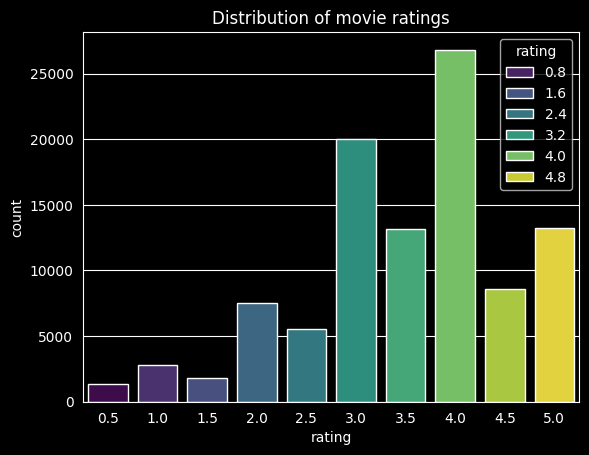

In [3]:
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis')
plt.title('Distribution of movie ratings')
plt.show()

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


First, we will extract the release year from the movie title.

In [5]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)', expand=False)
print(f'Missing years: {movies["year"].isnull().sum()}')
movies['year']

Missing years: 13


0       1995
1       1995
2       1995
3       1995
4       1995
        ... 
9737    2017
9738    2017
9739    2017
9740    2018
9741    1991
Name: year, Length: 9742, dtype: object

In [6]:
import warnings
warnings.filterwarnings('ignore')
# We added this because there would be a warning if we tried to drop on a slice of df

In [7]:
movies = movies.dropna(subset=['year'])
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
movies = movies.dropna(subset=['year'])
print(f'After cleaning: {len(movies)}')

After cleaning: 9729


Now, let's analyze the genres.

In [8]:
movies['genre_list'] = movies['genres'].str.split('|')
genre_frequency = Counter(g for genres in movies['genre_list'] for g in genres)
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['genre', 'count']
print(f'There are {len(genre_frequency)} genres in total.')
genre_frequency_df

There are 20 genres in total.


,genre,count
0,Adventure,1263
1,Animation,611
2,Children,664
3,Comedy,3756
4,Fantasy,779
5,Romance,1596
6,Drama,4359
7,Action,1827
8,Crime,1199
9,Thriller,1892


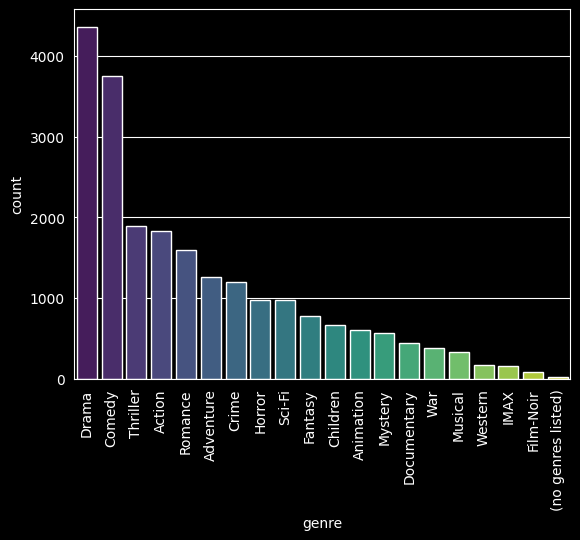

In [9]:
sns.barplot(x='genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), hue='genre', palette='viridis')
plt.xticks(rotation=90)
plt.show()

Now we want to one-encode the genres of the movies. Since we'll be training an autoencoder and learning embeddings from metadata, there is no label leakage possible, so we can simply transform the whole dataset.

In [10]:
mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genre_list']),
    columns=['genre_' + g for g in mlb.classes_],
    index=movies.index
)

movies = pd.concat([movies, genre_encoded], axis=1)
one_hot_genre_cols = ['genre_' + g for g in mlb.classes_]

print(f'Genres: {[g.replace("genre_","") for g in one_hot_genre_cols]}')

Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [11]:
movies.head()

,movieId,title,genres,year,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,"[Adventure, Animation, Children, Comedy, Fantasy]",0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,"[Adventure, Children, Fantasy]",0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,"[Comedy, Romance]",0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,"[Comedy, Drama, Romance]",0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995,[Comedy],0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now let's calculate some ratings stats.

In [12]:
movie_stats = ratings.groupby('movieId').agg(
    avg_rating  = ('rating', 'mean'),
    num_ratings = ('rating', 'count'),
    rating_std  = ('rating', 'std'),
).reset_index()
movie_stats['rating_std'] = movie_stats['rating_std'].fillna(0)
movie_stats.head()

,movieId,avg_rating,num_ratings,rating_std
0,1,3.920930,215,0.834859
1,2,3.431818,110,0.881713
2,3,3.259615,52,1.054823
3,4,2.357143,7,0.852168
4,5,3.071429,49,0.907148


Let's see which movie has the highest average rating.

In [13]:
highest_rated = ratings.groupby('movieId')[['rating']].mean()['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres,year,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
48,53,Lamerica (1994),Adventure|Drama,1994,"[Adventure, Drama]",0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
ratings[ratings['movieId'] == highest_rated]

,userId,movieId,rating,timestamp
13368,85,53,5.0,889468268
96115,603,53,5.0,963180003


*L'America* has only 2 five-star ratings, which was enough to make it the highest rated movie. This tells us that the standard average is not representable enough, so we'll have to use the **Bayesian average**. After that, movies with fewer ratings will get "shrunk" toward the global average, while movies with many ratings will stay closer to their actual average.

In [15]:
C = movie_stats['num_ratings'].mean()
m = movie_stats['avg_rating'].mean()
movie_stats['bayesian_avg'] = (C * m + movie_stats['avg_rating'] * movie_stats['num_ratings']) / (C + movie_stats['num_ratings'])

movies = movies.merge(movie_stats, on='movieId', how='left')
movies[['avg_rating','num_ratings','rating_std','bayesian_avg']] = \
    movies[['avg_rating','num_ratings','rating_std','bayesian_avg']].fillna(0)

movies[['title','avg_rating','num_ratings','bayesian_avg']].sort_values(by='bayesian_avg', inplace=False, ascending=False)

,title,avg_rating,num_ratings,bayesian_avg
277,"Shawshank Redemption, The (1994)",4.429022,317.0,4.392070
659,"Godfather, The (1972)",4.289062,192.0,4.236457
2226,Fight Club (1999),4.272936,218.0,4.227052
224,Star Wars: Episode IV - A New Hope (1977),4.231076,251.0,4.192646
46,"Usual Suspects, The (1995)",4.237745,204.0,4.190567
...,...,...,...,...
4506,"Road Home, The (Wo de fu qin mu qin) (1999)",0.000000,0.0,0.000000
5452,Mutiny on the Bounty (1962),0.000000,0.0,0.000000
5957,"Browning Version, The (1951)",0.000000,0.0,0.000000
4037,"Chosen, The (1981)",0.000000,0.0,0.000000


We can now see that Bayesian average gives us a better sense of which movies are actually highly rated.

In [16]:
print(f"Number of movies with no ratings: {len(movies[movies['num_ratings'] == 0])}")

Number of movies with no ratings: 18


Now we have to scale the data.

In [17]:
scaler = MinMaxScaler()
movies['year_norm'] = scaler.fit_transform(movies[['year']])
movies['num_ratings_norm'] = scaler.fit_transform(movies[['num_ratings']])
movies['avg_rating_norm'] = movies['avg_rating'] / 5.0
movies['bayesian_norm'] = movies['bayesian_avg'] / 5.0
movies['rating_std_norm'] = scaler.fit_transform(movies[['rating_std']])

content_feature_cols = one_hot_genre_cols + [
    'year_norm', 'num_ratings_norm', 'avg_rating_norm', 'bayesian_norm', 'rating_std_norm'
]

print(f'Content features: {len(content_feature_cols)}')

Content features: 25


Next, we are making a sparse matrix for user ratings for movies.

In [18]:
user_cat  = ratings['userId'].astype('category')
movie_cat = ratings['movieId'].astype('category')

# rows - users, columns - movies
R = csr_matrix(
    (ratings['rating'].values,
     (user_cat.cat.codes.values, movie_cat.cat.codes.values)),
    shape=(user_cat.cat.categories.nunique(), movie_cat.cat.categories.nunique())
)

print(f'User-movie matrix: {R.shape}')
print(f'Sparsity: {1 - R.nnz/(R.shape[0]*R.shape[1]):.1%}')

User-movie matrix: (610, 9724)
Sparsity: 98.3%


Next step is **collaborative filtering with SVD (Singular Value Decomposition)**. We are now extracting latent factors from user-movie rating patterns using matrix factorization. We want for SVD to learn movie embeddings based on how users rated them, so we first have to transpose our matrix $R$. We will keep only the 32 strongest latent dimensions, so after the transformation, each movie becomes a 32-dimensional vector.

In [19]:
# Using SVD to break into 3 smaller matrices
n_factors = 32
svd = TruncatedSVD(n_components=n_factors, random_state=42)
movie_latent = svd.fit_transform(R.T)

print(f'Explained variance (SVD): {svd.explained_variance_ratio_.sum():.3f}')
print(f'Movie latent matrix: {movie_latent.shape}')

Explained variance (SVD): 0.490
Movie latent matrix: (9724, 32)


In [20]:
# Normalize each movie's latent vector
norms = np.linalg.norm(movie_latent, axis=1, keepdims=True) + 1e-8  # add a small number to avoid division by zero
movie_latent_norm = movie_latent / norms

code_to_movie_id = dict(enumerate(movie_cat.cat.categories))
latent_cols = [f'svd_{i}' for i in range(n_factors)]
latent_df = pd.DataFrame(movie_latent_norm, columns=latent_cols)
latent_df['movieId'] = [code_to_movie_id[i] for i in range(len(latent_df))]
print(f'Latent factor DataFrame: {latent_df.shape}')
latent_df.head()

Latent factor DataFrame: (9724, 33)


,svd_0,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,...,svd_23,svd_24,svd_25,svd_26,svd_27,svd_28,svd_29,svd_30,svd_31,movieId
0,0.807988,-0.136921,0.321794,0.006158,-0.040492,0.102808,0.189002,-0.046925,0.024939,0.030460,...,-0.047930,-0.042637,-0.018202,-0.014047,-0.056507,-0.027629,0.029763,0.130132,0.143215,1
1,0.761966,-0.017679,0.401988,-0.319485,-0.113671,-0.019107,0.161287,-0.141394,-0.125668,0.008290,...,-0.109900,-0.074042,0.012675,0.093461,-0.061287,0.000245,0.017599,0.022820,-0.059481,2
2,0.528916,-0.355439,0.214052,-0.396974,0.001486,-0.048693,-0.088467,-0.034014,0.203430,0.117017,...,-0.200771,0.089993,-0.069429,-0.107916,-0.117377,0.106607,0.076988,0.260566,-0.012340,3
3,0.199263,-0.354312,0.408427,-0.102286,-0.314780,-0.375389,0.091855,-0.226007,0.033895,0.006012,...,-0.307935,0.018332,0.051203,0.012859,-0.088717,0.227507,0.163504,-0.105331,-0.009553,4
4,0.448932,-0.197698,0.347413,-0.326530,-0.274668,-0.123738,0.095954,-0.096881,0.098011,0.090578,...,-0.323358,-0.060103,-0.023971,-0.217256,-0.052733,0.165734,0.028011,0.083844,-0.053335,5


In [21]:
# Combining all features
original_feature_cols = ['movieId', 'title', 'genres', 'year'] + content_feature_cols
all_feature_cols = original_feature_cols + latent_cols

features = movies[original_feature_cols].copy()
features = features.merge(latent_df, on='movieId', how='inner')
features = features.dropna().reset_index(drop=True)

print(f'Total number of movies with full feature vectors: {len(features)}')
print(f'Total number of movie features: {len(all_feature_cols)}')
print(f'Number of original movie features: {len(original_feature_cols)}')
print(f'Number of SVD latent features: {len(latent_cols)}')
features.head() # final dataframe ready for training
print(features)

Total number of movies with full feature vectors: 9711
Total number of movie features: 61
Number of original movie features: 29
Number of SVD latent features: 32
      movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9706   193581  Black Butler: Book of the Atlantic (2017)   
9707   193583               No Game No Life: Zero (2017)   
9708   193585                               Flint (2017)   
9709   193587        Bungo Stray Dogs: Dead Apple (2018)   
9710   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  year  \
0     Adventure|Animation|Children|Comedy|Fantasy  1995   

Finally, our prepared data is stored inside of the `features` dataframe. \
Each movie is represented by a 32-dimensional latent vector obtained using SVD. \
Each `svd_i` column corresponds to one latent factor that captures hidden co-watching patterns between users and movies.

### Example: *Toy Story (1995)*

- `svd_30 = 0.130132`
- `svd_31 = -0.143215`

This means:

- Toy Story has a **positive contribution** to latent factor 30.
- Toy Story has a **negative contribution** to latent factor 31.

In other words, the movie aligns strongly with the behavioral pattern captured by factor 30,  
while it is positioned oppositely along factor 31.

These latent factors do not correspond to explicit genres. Instead, they represent hidden viewing patterns learned from user behavior.

In [22]:
content_latent_cols = content_feature_cols + latent_cols
X = features[content_latent_cols].values.astype(np.float32)
X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

In [23]:
X_train.shape

(8739, 57)

In [24]:
X_val.shape

(972, 57)

In [25]:
np.save('../models/X_train.npy', X_train)
np.save('../models/X_val.npy', X_val)

# Movie metadata + full feature table
features[['movieId','title','genres','year']].to_csv('../data/movie_index.csv', index=False)
features.to_csv('../data/movie_features.csv', index=False)

# Column list so other notebooks know the feature order
with open('../data/feature_cols.txt', 'w') as f:
    f.write('\n'.join(content_latent_cols))